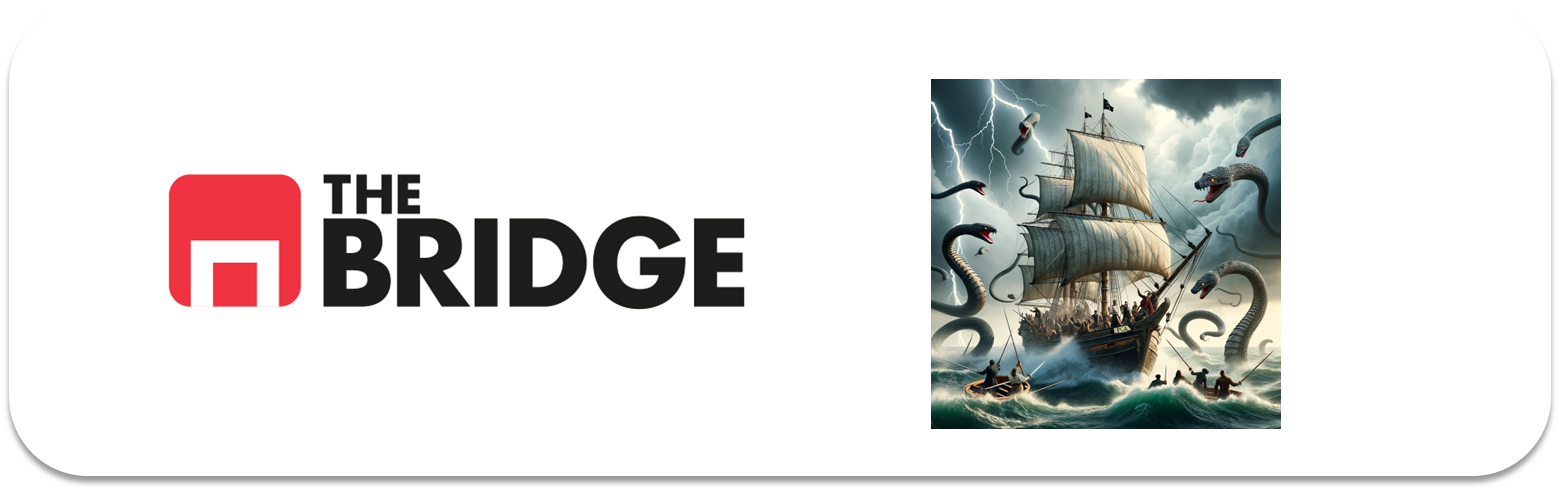

## PRACTICA OBLIGATORIA: **No Supervisado: PCA**

* La práctica obligatoria de esta unidad consiste en aplicar PCA a un dataset de imágenes con diferentes objetivos y compromisos. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### El problema de negocio

El Caesar Palace de las Vegas está planificando la instalación de mil quininetas microcámaras en los accesos a sus instalaciones para las próximas sesiones del "Poker World Championship". Estas microcámaras tienen la peculiaridad de que son capaces de tomar fotos encuadradas de las caras y la desventaja de que no tienen un gran ancho de banda de comunicación. (Las había de más ancho y de mayor precio...). NOTA: El ancho de banda limita el tamaño de las imágenes que pueden enviar las microcámaras).

El objetivo de las microcámaras es el de detectar personas "non-gratas" en tiempo real, pudiendo posprocesar las imágenes para poder detectar si han accedido a las instalaciones personas que estuvieran perseguidas por la ley, en los bancos de datos de los casinos identificadas como "peligrosas" (no se sabe si para el resto de personas o para los beneficios de los casinos) y en las listas de no admisión de jugadores adictos. Por eso no necesitan procesar los datos en tiempo real, pero sí enviarlos a un repositorio central. 

¿Cuál es su problema? O bien comprimen las imágenes y las procesan comprimidas en cada microcámara (pueden comprimir muy rápido pero no tienen cpu para procesarlas sin comprimir) o bien las comprimen y las mandan a un servidor central muy rápido (por eso ti) donde se descomprimirían y se analizarían. Analizar quiere decir en este contexto, pasarles un modelo de clasificación que determine si la persona de la imagen es una de las listas prohibidas (o sea que clasifique la imágen).  

Nos han enviado un dataset y con él debemos estudiar cuál de las dos soluciones es más interesante y dar recomendaciones al respecto. Vamos a ello.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import balanced_accuracy_score

import warnings
warnings.filterwarnings('ignore')

# bootcampviztools debe estar en el mismo directorio que este notebook
import sys
sys.path.append('.')
from bootcampviztools import *

### #1 MODELO DE BASE

**Objetivo:** Construir un modelo baseline de clasficación de imágenes que las trate sin comprimir (es decir usando todos sus píxeles).

Para conseguir el objetivo, primero descarga el dataset de las caras de Olivetti que ya has utilizado anteriormente, empleando las funciones de sklearn necesarias. Luego, construye un clasificador con el modelo que consideres más apropiado y todas las features del dataset. Eso sí, recuerda hacer lo siguiente:

1. Construir un data frame con los datos 
2. Hacer un split en train y test con al menos 80 instancias en el test y estratificado según el target. Este split se ha de mantener en el resto de la práctica
3. Hacer un quick miniEDA o justificar el no hacerlo.
4. Medir la recall media (“balanced_accuracy”) sobre cross validation con 5 folds y sobre el conjunto de test y guarda ambas para usarlas como baseline en las siguientes partes




In [2]:
olivetti = fetch_olivetti_faces(shuffle=True, random_state=42)
X = olivetti.data    # 400 muestras x 4096 features (imagenes 64x64 pixeles)
y = olivetti.target  # 40 clases (10 imagenes por persona)

# Crear DataFrame con los datos
df = pd.DataFrame(X)
df['target'] = y

print(f'Shape del dataset: {X.shape}')
print(f'Numero de clases:  {len(np.unique(y))} personas')
print(f'Shape DataFrame:   {df.shape}')
df.head(3)

Shape del dataset: (400, 4096)
Numero de clases:  40 personas
Shape DataFrame:   (400, 4097)


,0,1,2,3,4,5,6,7,8,9,...,4087,4088,4089,4090,4091,4092,4093,4094,4095,target
0,0.198347,0.235537,0.351240,0.409091,0.421488,0.429752,0.500000,0.528926,0.524793,0.553719,...,0.508264,0.524793,0.504132,0.483471,0.471074,0.285124,0.061983,0.128099,0.090909,20
1,0.185950,0.128099,0.115702,0.132231,0.185950,0.268595,0.433884,0.541322,0.570248,0.586777,...,0.396694,0.409091,0.301653,0.421488,0.462810,0.247934,0.190083,0.210744,0.210744,28
2,0.508264,0.603306,0.619835,0.628099,0.657025,0.665289,0.690083,0.727273,0.743802,0.768595,...,0.301653,0.305785,0.314050,0.326446,0.338843,0.330579,0.334711,0.342975,0.342975,3


In [3]:
# 2. Split train/test estratificado con al menos 80 instancias en test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Instancias en test: {len(X_test)} (minimo requerido: 80 OK)')
print(f'Clases en train: {len(np.unique(y_train))} | Clases en test: {len(np.unique(y_test))}')
print(f'Muestras por clase en test: {pd.Series(y_test).value_counts().iloc[0]} (estratificado)')

Train: (320, 4096) | Test: (80, 4096)
Instancias en test: 80 (minimo requerido: 80 OK)
Clases en train: 40 | Clases en test: 40
Muestras por clase en test: 2 (estratificado)


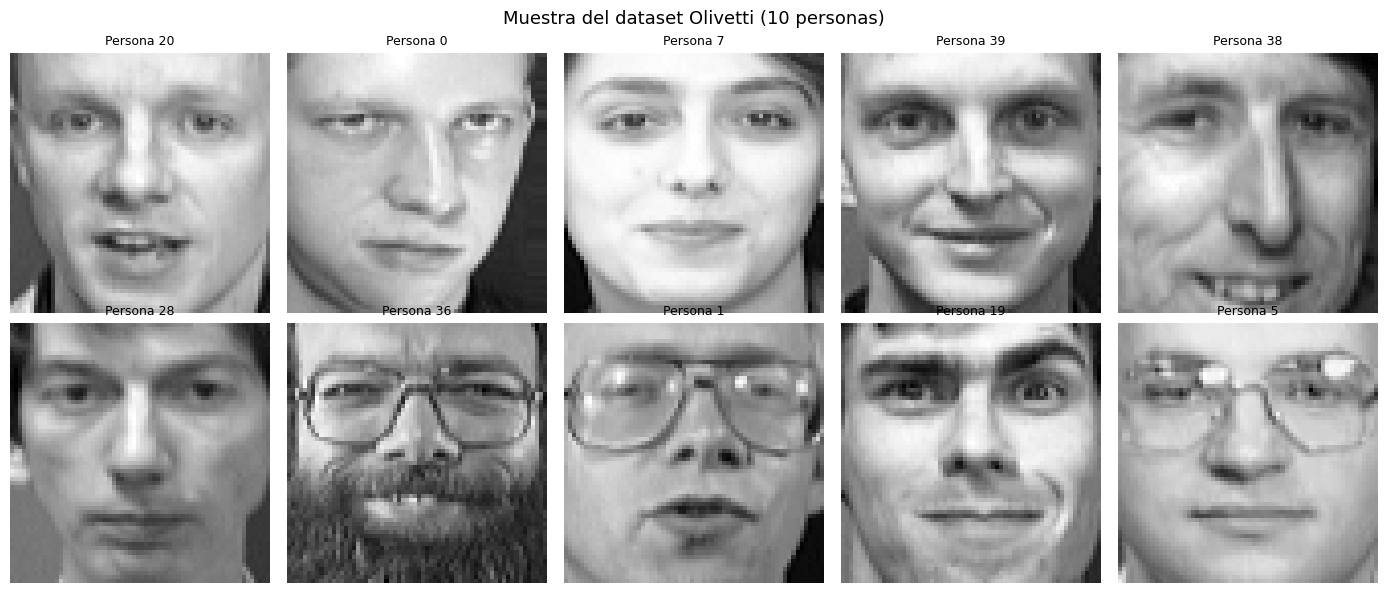

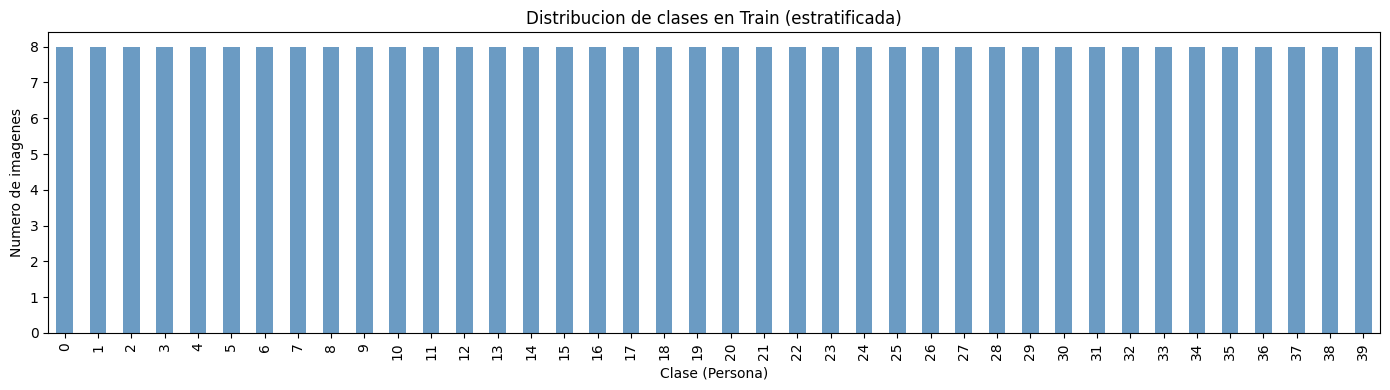

Resumen:
  Total muestras: 400
  Features (pixeles): 4096 (64x64)
  Clases: 40 personas
  Muestras por clase: 10 (balanceado)
  Rango de pixeles: [0.000, 1.000] (normalizados)

Justificacion miniEDA: dataset perfectamente balanceado, pixeles normalizados [0,1],
sin valores nulos. No requiere preprocesamiento adicional para KNN/SVM.


In [4]:
#Mini EDA
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Muestra del dataset Olivetti (10 personas)', fontsize=13)
for i in range(5):
    for j in range(2):
        idx = i * 10 + j
        axes[j, i].imshow(X[idx].reshape(64, 64), cmap='gray')
        axes[j, i].set_title(f'Persona {y[idx]}', fontsize=9)
        axes[j, i].axis('off')
plt.tight_layout()
plt.show()

# Distribucion de clases en train
fig, ax = plt.subplots(figsize=(14, 4))
pd.Series(y_train).value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Distribucion de clases en Train (estratificada)')
ax.set_xlabel('Clase (Persona)')
ax.set_ylabel('Numero de imagenes')
plt.tight_layout()
plt.show()

print(f'Resumen:')
print(f'  Total muestras: {X.shape[0]}')
print(f'  Features (pixeles): {X.shape[1]} (64x64)')
print(f'  Clases: {len(np.unique(y))} personas')
print(f'  Muestras por clase: {pd.Series(y).value_counts().iloc[0]} (balanceado)')
print(f'  Rango de pixeles: [{X.min():.3f}, {X.max():.3f}] (normalizados)')
print()
print('Justificacion miniEDA: dataset perfectamente balanceado, pixeles normalizados [0,1],')
print('sin valores nulos. No requiere preprocesamiento adicional para KNN/SVM.')

In [5]:
# 4. Modelo baseline: KNN (algoritmo visto en clase) con todos los 4096 features
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

clf_base = KNeighborsClassifier(n_neighbors=3)

# Cross-validation (5 folds, balanced_accuracy)
cv_scores_base = cross_val_score(clf_base, X_train, y_train, cv=cv, scoring='balanced_accuracy')
baseline_cv = cv_scores_base.mean()

# Score en test
clf_base.fit(X_train, y_train)
y_pred_base = clf_base.predict(X_test)
baseline_test = balanced_accuracy_score(y_test, y_pred_base)


print('MODELO BASELINE (KNN, k=3, 4096 features sin comprimir)')

print(f'  Balanced Accuracy CV (5-fold): {baseline_cv:.4f} ({baseline_cv*100:.2f}%)')
print(f'  Balanced Accuracy Test:{baseline_test:.4f} ({baseline_test*100:.2f}%)')
print(f'  Scores por fold: {[round(s,4) for s in cv_scores_base]}')


# Guardar para comparaciones posteriores
print(f'\nbaseline_cv   = {baseline_cv:.4f}  <- referencia para partes 2 y 3')
print(f'baseline_test = {baseline_test:.4f}  <- referencia para partes 2 y 3')

MODELO BASELINE (KNN, k=3, 4096 features sin comprimir)
  Balanced Accuracy CV (5-fold): 0.8425 (84.25%)
  Balanced Accuracy Test:0.8875 (88.75%)
  Scores por fold: [np.float64(0.8875), np.float64(0.825), np.float64(0.8625), np.float64(0.8625), np.float64(0.775)]

baseline_cv   = 0.8425  <- referencia para partes 2 y 3
baseline_test = 0.8875  <- referencia para partes 2 y 3


### #2 MODELO PARA LAS MICROCÁMARAS
**Objetivo:** Construir un modelo que pueda funcionar en las microcámaras, es decir que pueda funcionar con datos comprimidos.

Para cumplir con el objetivo se os ocurre emplear la doble propiedad de la PCA, que permite comprimir datos y mantener la capacidad informativa de estos. Sigue los siguientes pasos:
1. Instancia un objeto PCA sobre los datos de Train sin especificar ni componentes ni varianza explicada (o sea sin pasar argumentos).
2. Escoge un rango de valores para el número de PCAs que permitan por lo menos una compresión de la imagen de entre el 0.2% y el 2.5% (prueba al menos 5 valores). NOTA: La compresión es la reducción total, es decir una reducción del 1% quiere decir que el dataset se reduce a un 1% de su tamaño original)
3. Para el rango anterior entrena un modelo de clasificación y apunta su scoring en una validación cruzada de 5 folds y métrica el recall medio y su scoring contra test.
4. Muestra en un dataframe el valor de numero de componentes principales empleado, el scoring en CV, el scoring contra test, el % de compresión, la diferencia con el scoring de CV del modelo base, la diferencia con el scoring en test.
5. Escoge el número de componentes que permitirían tener la mayor compresión con una pérdida inferior a 3 puntos porcentuales tanto en CV como en test. Si no hay escoge el que tenga una pérdida inferior a 5 puntos porcentuales. 

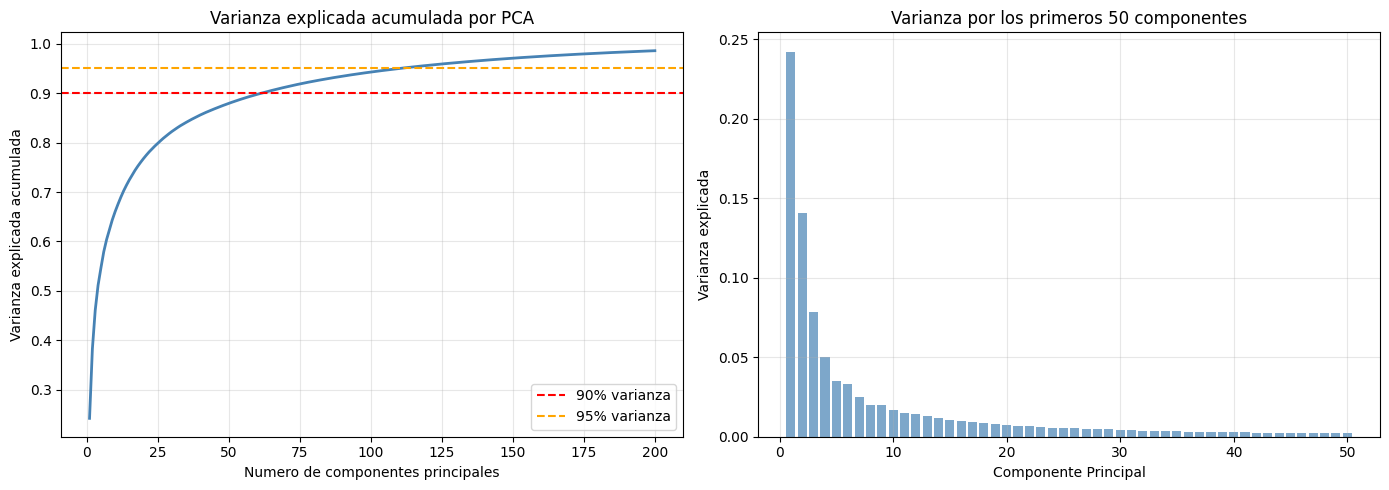

Relacion compresion <-> n_components (sobre 4096 features):
  0.2% ->   8 componentes | varianza explicada: 62.4%
  0.5% ->  20 componentes | varianza explicada: 76.8%
  1.0% ->  40 componentes | varianza explicada: 85.6%
  1.5% ->  61 componentes | varianza explicada: 89.9%
  2.0% ->  81 componentes | varianza explicada: 92.5%
  2.5% -> 102 componentes | varianza explicada: 94.4%


In [6]:
# 1. PCA sin argumentos para explorar la varianza explicada
pca_full = PCA(random_state=42)
pca_full.fit(X_train)

n_features = X_train.shape[1]  # 4096 features
varianza_acum = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, 201), varianza_acum[:200], color='steelblue', lw=2)
axes[0].axhline(y=0.90, color='red', linestyle='--', label='90% varianza')
axes[0].axhline(y=0.95, color='orange', linestyle='--', label='95% varianza')
axes[0].set_xlabel('Numero de componentes principales')
axes[0].set_ylabel('Varianza explicada acumulada')
axes[0].set_title('Varianza explicada acumulada por PCA')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(range(1, 51), pca_full.explained_variance_ratio_[:50], color='steelblue', alpha=0.7)
axes[1].set_xlabel('Componente Principal')
axes[1].set_ylabel('Varianza explicada')
axes[1].set_title('Varianza por los primeros 50 componentes')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Rango de compresion 0.2% a 2.5%
# Compresion% = n_components / n_features * 100
# -> n_components = comp% / 100 * n_features
print('Relacion compresion <-> n_components (sobre 4096 features):')
for pct in [0.2, 0.5, 1.0, 1.5, 2.0, 2.5]:
    nc = int(pct / 100 * n_features)
    var = varianza_acum[nc - 1] * 100 if nc > 0 else 0
    print(f'  {pct:.1f}% -> {nc:3d} componentes | varianza explicada: {var:.1f}%')

In [7]:
# 2 & 3. Entrenar KNN para cada nivel de compresion entre 0.2% y 2.5%
# Valores elegidos: 8, 20, 41, 61, 82, 102 componentes
# -> ~0.2%, ~0.5%, ~1.0%, ~1.5%, ~2.0%, ~2.5% de los 4096 features

n_components_part2 = [8, 20, 41, 61, 82, 102]
results_part2 = []

for n_comp in n_components_part2:
    pca = PCA(n_components=n_comp, random_state=42)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca  = pca.transform(X_test)

    clf = KNeighborsClassifier(n_neighbors=3)

    # CV
    cv_scores = cross_val_score(clf, X_train_pca, y_train, cv=cv, scoring='balanced_accuracy')
    cv_score = cv_scores.mean()

    # Test
    clf.fit(X_train_pca, y_train)
    test_score = balanced_accuracy_score(y_test, clf.predict(X_test_pca))

    compression_pct = n_comp / n_features * 100

    results_part2.append({
        'n_components':      n_comp,
        'Compresion_%':      round(compression_pct, 3),
        'CV_score':          round(cv_score, 4),
        'Test_score':        round(test_score, 4),
        'Diff_CV_vs_Base':   round(cv_score   - baseline_cv,   4),
        'Diff_Test_vs_Base': round(test_score - baseline_test, 4),
    })
    print(f'n_comp={n_comp:4d} ({compression_pct:.2f}%) | CV: {cv_score:.4f} | Test: {test_score:.4f}')

n_comp=   8 (0.20%) | CV: 0.6900 | Test: 0.8000
n_comp=  20 (0.49%) | CV: 0.8150 | Test: 0.9000
n_comp=  41 (1.00%) | CV: 0.8300 | Test: 0.9250
n_comp=  61 (1.49%) | CV: 0.8375 | Test: 0.9125
n_comp=  82 (2.00%) | CV: 0.8425 | Test: 0.9000
n_comp= 102 (2.49%) | CV: 0.8425 | Test: 0.9000


Resultados - Modelo para Microcamaras (clasificacion sobre componentes PCA):
 n_components  Compresion_%  CV_score  Test_score  Diff_CV_vs_Base  Diff_Test_vs_Base
            8         0.195    0.6900      0.8000          -0.1525            -0.0875
           20         0.488    0.8150      0.9000          -0.0275             0.0125
           41         1.001    0.8300      0.9250          -0.0125             0.0375
           61         1.489    0.8375      0.9125          -0.0050             0.0250
           82         2.002    0.8425      0.9000           0.0000             0.0125
          102         2.490    0.8425      0.9000           0.0000             0.0125
Baseline CV: 0.8425 | Baseline Test: 0.8875


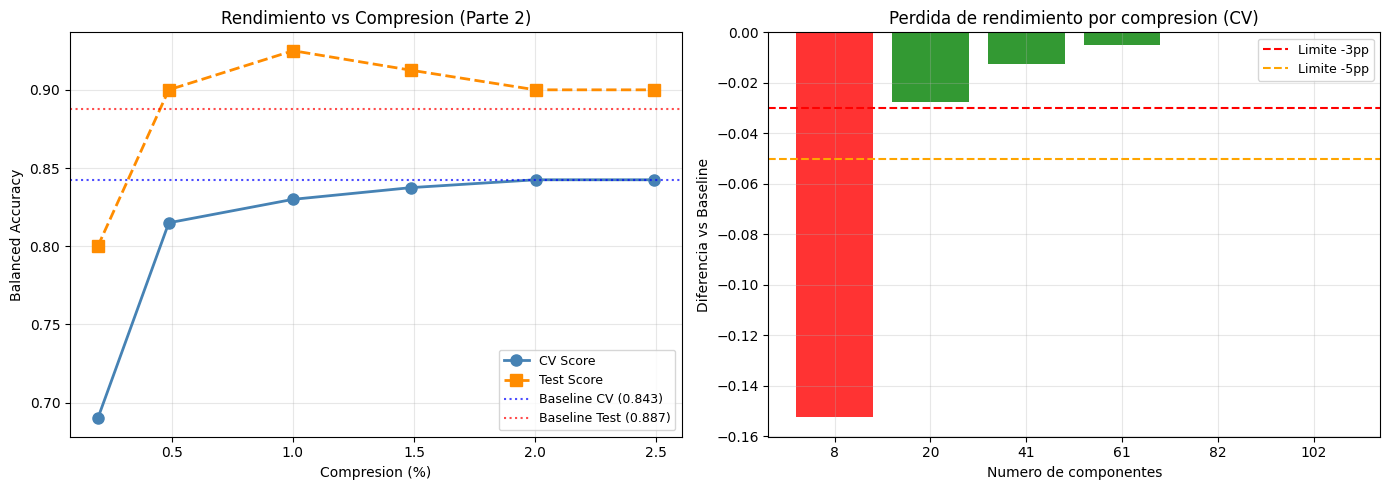

In [8]:
# 4. DataFrame con resultados
df_results2 = pd.DataFrame(results_part2)
print('Resultados - Modelo para Microcamaras (clasificacion sobre componentes PCA):')
print('=' * 80)
print(df_results2.to_string(index=False))
print('=' * 80)
print(f'Baseline CV: {baseline_cv:.4f} | Baseline Test: {baseline_test:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_results2['Compresion_%'], df_results2['CV_score'],   'o-',
             color='steelblue',  label='CV Score',   lw=2, markersize=8)
axes[0].plot(df_results2['Compresion_%'], df_results2['Test_score'], 's--',
             color='darkorange', label='Test Score', lw=2, markersize=8)
axes[0].axhline(y=baseline_cv,   color='blue', linestyle=':',  alpha=0.7,
                label=f'Baseline CV ({baseline_cv:.3f})')
axes[0].axhline(y=baseline_test, color='red',  linestyle=':',  alpha=0.7,
                label=f'Baseline Test ({baseline_test:.3f})')
axes[0].set_xlabel('Compresion (%)')
axes[0].set_ylabel('Balanced Accuracy')
axes[0].set_title('Rendimiento vs Compresion (Parte 2)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

colores_bar = ['green' if d >= -0.03 else 'red' for d in df_results2['Diff_CV_vs_Base']]
axes[1].bar(df_results2['n_components'].astype(str),
            df_results2['Diff_CV_vs_Base'], color=colores_bar, alpha=0.8)
axes[1].axhline(y=-0.03, color='red',    linestyle='--', label='Limite -3pp')
axes[1].axhline(y=-0.05, color='orange', linestyle='--', label='Limite -5pp')
axes[1].set_xlabel('Numero de componentes')
axes[1].set_ylabel('Diferencia vs Baseline')
axes[1].set_title('Perdida de rendimiento por compresion (CV)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# 5. Seleccion del optimo
print('\n5. SELECCION DE COMPONENTES OPTIMOS:')
candidatos = df_results2[
    (df_results2['Diff_CV_vs_Base']   >= -0.03) &
    (df_results2['Diff_Test_vs_Base'] >= -0.03)
]

umbral_usado = '3pp'
if candidatos.empty:
    candidatos = df_results2[
        (df_results2['Diff_CV_vs_Base']   >= -0.05) &
        (df_results2['Diff_Test_vs_Base'] >= -0.05)
    ]
    umbral_usado = '5pp (no habia candidatos con 3pp)'

if not candidatos.empty:
    mejor2 = candidatos.loc[candidatos['n_components'].idxmin()]
    n_best_part2 = int(mejor2['n_components'])
    print(f'Umbral usado: {umbral_usado}')
    print(candidatos[['n_components','Compresion_%','CV_score','Test_score',
                       'Diff_CV_vs_Base','Diff_Test_vs_Base']].to_string(index=False))
    print(f'\n-> SELECCIONADO: {n_best_part2} componentes ({float(mejor2["Compresion_%"]):.3f}% compresion)')
    print(f'   CV Score:   {float(mejor2["CV_score"]):.4f} | Diff vs base: {float(mejor2["Diff_CV_vs_Base"]):+.4f}')
    print(f'   Test Score: {float(mejor2["Test_score"]):.4f} | Diff vs base: {float(mejor2["Diff_Test_vs_Base"]):+.4f}')
else:
    n_best_part2 = n_components_part2[0]
    print('Ninguna configuracion cumple el criterio de perdida aceptable.')


5. SELECCION DE COMPONENTES OPTIMOS:
Umbral usado: 3pp
 n_components  Compresion_%  CV_score  Test_score  Diff_CV_vs_Base  Diff_Test_vs_Base
           20         0.488    0.8150      0.9000          -0.0275             0.0125
           41         1.001    0.8300      0.9250          -0.0125             0.0375
           61         1.489    0.8375      0.9125          -0.0050             0.0250
           82         2.002    0.8425      0.9000           0.0000             0.0125
          102         2.490    0.8425      0.9000           0.0000             0.0125

-> SELECCIONADO: 20 componentes (0.488% compresion)
   CV Score:   0.8150 | Diff vs base: -0.0275
   Test Score: 0.9000 | Diff vs base: +0.0125


### #3 COMPRESION PARA CLASIFICACION POSTERIOR

**Objetivo**: Obtener el número de componentes que permita una compresión menor y al tiempo que el modelo en el servidor central no baje su rendimiento respecto a no usar imágenes comprimidas.

Para esta parte la idea que se os ha ocurrido es emplear también la PCA como compresor ya que así siempre podrían pasar a la opción anterior si eso fuese suficiente. Pero en este caso no vamos a utilizar el dataset comprimido con las PCAs para detectar las caras, sino el dataset una vez descomprimido (recuerda que puede emplear `inverse_transform` para "descomprimir"). Los pasos a seguir son:

1. Escoge un rango de valores que  permitan una compresión aún mayor (recuerda que el ancho de banda es mínimo) entre el 1 por mil y el 1 por ciento. Escoge 5 valores de número de PCAs que permitan movernos en ese rango.
2. Para cada uno de esos valores: aplica la PCA al X_train, obten un X_train_unzipped aplicando la inversa de la PCA y entrena un modelo de clasificación y pruébalo contra test, apunta el balanced accuracy.
3. Crea un dataframe o haz un visualización comparando como es la medidad de balance accuracy para cada valor de número de pcas escogido y cuál su factor de compresión. 
4. Sabiendo que no podemos perder más de 3 puntos porcentuales respecto al baseline, ¿qué numero de PCA escogerías?

In [10]:
# 1. Rango: 1 por mil (0.1%) a 1% de 4096 features
# 0.1% x 4096 = 4.1 -> 4 componentes
# 1.0% x 4096 = 40.96 -> 41 componentes

n_components_part3 = [4, 8, 12, 20, 41]

print('Rango de compresion para la Parte 3:')
for nc in n_components_part3:
    print(f'  {nc:3d} componentes -> {nc/n_features*100:.3f}% de compresion')
print()

results_part3 = []

for n_comp in n_components_part3:
    # Aplicar PCA al conjunto de entrenamiento
    pca = PCA(n_components=n_comp, random_state=42)
    X_train_pca      = pca.fit_transform(X_train)
    X_train_unzipped = pca.inverse_transform(X_train_pca)  # reconstruccion

    # En produccion el test tambien llegara comprimido -> descomprimir antes de clasificar
    X_test_pca      = pca.transform(X_test)
    X_test_unzipped = pca.inverse_transform(X_test_pca)

    # Clasificador entrenado sobre imagenes reconstruidas
    clf = KNeighborsClassifier(n_neighbors=3)
    clf.fit(X_train_unzipped, y_train)
    test_score = balanced_accuracy_score(y_test, clf.predict(X_test_unzipped))

    compression_pct = n_comp / n_features * 100
    results_part3.append({
        'n_components':  n_comp,
        'Compresion_%':  round(compression_pct, 4),
        'Test_score':    round(test_score, 4),
        'Diff_vs_Base':  round(test_score - baseline_test, 4),
    })
    print(f'n_comp={n_comp:3d} ({compression_pct:.3f}%) | Test: {test_score:.4f} '
          f'| Delta vs Base: {test_score-baseline_test:+.4f}')

Rango de compresion para la Parte 3:
    4 componentes -> 0.098% de compresion
    8 componentes -> 0.195% de compresion
   12 componentes -> 0.293% de compresion
   20 componentes -> 0.488% de compresion
   41 componentes -> 1.001% de compresion

n_comp=  4 (0.098%) | Test: 0.5625 | Delta vs Base: -0.3250
n_comp=  8 (0.195%) | Test: 0.8000 | Delta vs Base: -0.0875
n_comp= 12 (0.293%) | Test: 0.8750 | Delta vs Base: -0.0125
n_comp= 20 (0.488%) | Test: 0.9000 | Delta vs Base: +0.0125
n_comp= 41 (1.001%) | Test: 0.9250 | Delta vs Base: +0.0375


Resultados Parte 3 - Compresion + Descompresion + Clasificacion:
 n_components  Compresion_%  Test_score  Diff_vs_Base
            4        0.0977      0.5625       -0.3250
            8        0.1953      0.8000       -0.0875
           12        0.2930      0.8750       -0.0125
           20        0.4883      0.9000        0.0125
           41        1.0010      0.9250        0.0375
Baseline Test: 0.8875


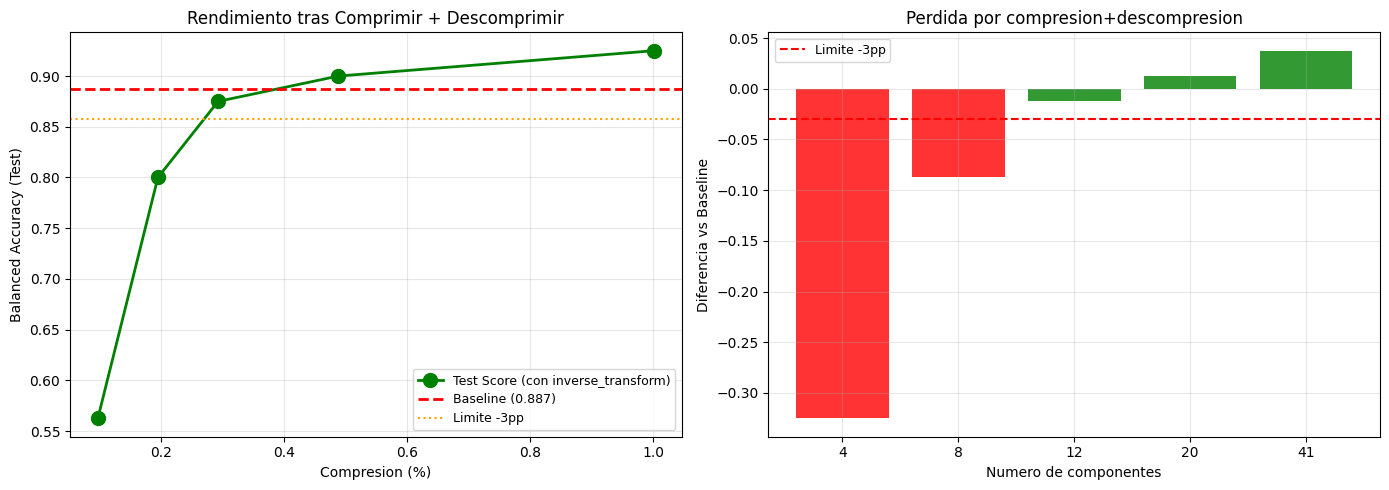

In [11]:
# 3. DataFrame + visualizacion
df_results3 = pd.DataFrame(results_part3)

print('Resultados Parte 3 - Compresion + Descompresion + Clasificacion:')
print('=' * 60)
print(df_results3.to_string(index=False))
print('=' * 60)
print(f'Baseline Test: {baseline_test:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_results3['Compresion_%'], df_results3['Test_score'],
             'o-', color='green', lw=2, markersize=10,
             label='Test Score (con inverse_transform)')
axes[0].axhline(y=baseline_test,        color='red',    linestyle='--', lw=2,
                label=f'Baseline ({baseline_test:.3f})')
axes[0].axhline(y=baseline_test - 0.03, color='orange', linestyle=':',  lw=1.5,
                label='Limite -3pp')
axes[0].set_xlabel('Compresion (%)')
axes[0].set_ylabel('Balanced Accuracy (Test)')
axes[0].set_title('Rendimiento tras Comprimir + Descomprimir')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

colores3 = ['green' if d >= -0.03 else 'red' for d in df_results3['Diff_vs_Base']]
axes[1].bar(df_results3['n_components'].astype(str),
            df_results3['Diff_vs_Base'], color=colores3, alpha=0.8)
axes[1].axhline(y=-0.03, color='red', linestyle='--', label='Limite -3pp')
axes[1].set_xlabel('Numero de componentes')
axes[1].set_ylabel('Diferencia vs Baseline')
axes[1].set_title('Perdida por compresion+descompresion')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# 4. Seleccion
print('\n4. QUE NUMERO DE PCA ESCOGERÍAS?')
print('-' * 50)
viables3 = df_results3[df_results3['Diff_vs_Base'] >= -0.03]

if not viables3.empty:
    sel3 = viables3.loc[viables3['n_components'].idxmin()]
    n_best_part3 = int(sel3['n_components'])
    print('Candidatos con perdida < 3pp:')
    print(viables3.to_string(index=False))
    print(f'\n-> SELECCIONARIA: {n_best_part3} componentes')
    print(f'   Compresion: {float(sel3["Compresion_%"]):.4f}% del tamano original')
    print(f'   Test Score: {float(sel3["Test_score"]):.4f}')
    print(f'   Diferencia vs baseline: {float(sel3["Diff_vs_Base"]):+.4f} pp')
else:
    mejor3 = df_results3.loc[df_results3['Diff_vs_Base'].idxmax()]
    n_best_part3 = int(mejor3['n_components'])
    print('Ningun valor logra mantener perdida < 3pp con tan alta compresion.')
    print(f'El mejor disponible: {n_best_part3} componentes | '
          f'Diff: {float(mejor3["Diff_vs_Base"]):+.4f}')
    print('Recomendacion: ampliar el rango de componentes o relajar el umbral.')


4. QUE NUMERO DE PCA ESCOGERÍAS?
--------------------------------------------------
Candidatos con perdida < 3pp:
 n_components  Compresion_%  Test_score  Diff_vs_Base
           12        0.2930       0.875       -0.0125
           20        0.4883       0.900        0.0125
           41        1.0010       0.925        0.0375

-> SELECCIONARIA: 12 componentes
   Compresion: 0.2930% del tamano original
   Test Score: 0.8750
   Diferencia vs baseline: -0.0125 pp


### #EXTRA

1. Para la segunda parte, visualiza en cuatro gráficos un scatter plot de las dos primeras componentes principales de la PCA escogida y colorea cada punto con las clases correspondientes a cada cara (como hay 40 clases, usa 10 por gráfico, 1-10 en el primero, 11-20 en el segundo, etc)
2. Para la tercer parte crea una función (modifica la de la práctica de la unidad de KMeans, por ejemplo) que permita ver la cara sin comprimir y la cara después de haberla descomprimido y haz una comprobación de cómo quedan (visualiza 5 caras por ejemplo) para cada uno de los valores de números de PCAs probados. Añade el caso para 150 y 320 PCs para que se vea que son las mismas claras con claridad.